<img src="logoucm.png" style="height: 200px">
<center style="color:#888"><br/></center>


<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos: Ana Marta Oliveira dos Santos, Mario Queipo Silva, Siria Catherine Iniguez Brito***</span></center></font>

<font size="5"><center><span style="color:#1B4F72">***Práctica 10: Teoría de Colas***</span></center></font>

En esta práctica simularemos y analizaremos los principales sistemas de colas. Los sistemas de colas son un caso particular de las cadenas de Markov en tiempo continuo (CTMC) que hemos estudiado en clase: el proceso de llegadas sigue un proceso de Poisson (como vimos en la práctica anterior) y los tiempos de servicio siguen una distribución exponencial.

### Importamos las librerías necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Marco Teórico

### Notación de Kendall: $A/B/c/K$
- $A$: distribución de tiempos entre llegadas ($M$ = Exponencial/Markoviana)
- $B$: distribución de tiempos de servicio ($M$ = Exponencial)
- $c$: número de servidores
- $K$: capacidad máxima del sistema (por defecto $\infty$)

### Parámetros y métricas
- $\lambda$: tasa de llegada
- $\mu$: tasa de servicio por servidor
- $\rho = \lambda / (c\mu)$: factor de utilización (debe ser $< 1$ para que el sistema sea estable)
- $L$, $L_q$: número medio de clientes en el sistema y en cola
- $W$, $W_q$: tiempo medio en el sistema y en cola

### Ley de Little
$$L = \lambda W \qquad L_q = \lambda W_q$$

### Fórmulas analíticas para M/M/1 ($\rho < 1$)
$$W = \frac{1}{\mu - \lambda} \qquad W_q = \frac{\rho}{\mu - \lambda} \qquad L = \frac{\rho}{1-\rho} \qquad L_q = \frac{\rho^2}{1-\rho}$$

## 2. Ejercicio 1: Simulación de una cola M/M/1

### 📌 Enunciado
Simula una cola M/M/1 con $\lambda = 0.8$, $\mu = 1.0$ y $n = 1000$ clientes.

1. Genera los tiempos entre llegadas ($\text{Exp}(\lambda)$) y los tiempos de servicio ($\text{Exp}(\mu)$).
2. Calcula para cada cliente: tiempo de llegada, tiempo de inicio de servicio, tiempo de fin de servicio, tiempo en cola y tiempo en el sistema.
3. Obtén el tiempo medio en cola $W_q$ y en el sistema $W$.
4. Compara con los valores teóricos e indica el factor de utilización $\rho$.

**Valores de referencia teóricos** ($\rho = 0.8$):
- $W = 1/(\mu - \lambda) = 1/0.2 = 5.000$
- $W_q = \rho/(\mu - \lambda) = 0.8/0.2 = 4.000$

In [6]:
# Parámetros
lmbda = 0.8
mu = 1.0
n_clientes = 1000
np.random.seed(42)

# Factor de utilización
rho = lmbda / mu
print(f"Factor de utilización ρ = λ/μ = {rho:.2f}")
print(f"El sistema {'es estable (ρ < 1)' if rho < 1 else 'NO es estable (ρ ≥ 1)'}")

# 1. Genera los tiempos entre llegadas y los tiempos de servicio
# Ojo: np.random.exponential requiere el parámetro de escala (beta), que es la inversa de la tasa (1/λ y 1/μ)
tiempos_entre_llegadas = np.random.exponential(1 / lmbda, n_clientes)
tiempos_servicio = np.random.exponential(1 / mu, n_clientes)

# 2. Calcula los tiempos de llegada acumulados
tiempos_llegada = np.cumsum(tiempos_entre_llegadas)

# 3. Calcula inicio y fin de servicio para cada cliente
inicio_servicio = np.zeros(n_clientes)
fin_servicio = np.zeros(n_clientes)

for i in range(n_clientes):
    if i == 0:
        # El primer cliente inicia su servicio al instante en que llega
        inicio_servicio[i] = tiempos_llegada[i]
    else:
        # Para el resto, el servicio empieza cuando llega el cliente o cuando el servidor queda libre (lo que ocurra último)
        inicio_servicio[i] = max(tiempos_llegada[i], fin_servicio[i-1])

    # El fin de servicio es el inicio más el tiempo de servicio asignado
    fin_servicio[i] = inicio_servicio[i] + tiempos_servicio[i]

# 4. Calcula tiempo en cola y tiempo en sistema
tiempo_en_cola = inicio_servicio - tiempos_llegada
tiempo_en_sistema = fin_servicio - tiempos_llegada

# 5. Muestra los resultados comparando con los valores teóricos
W_q_teo = rho / (mu - lmbda)
W_teo   = 1.0 / (mu - lmbda)

W_q_sim = np.mean(tiempo_en_cola)
W_sim = np.mean(tiempo_en_sistema)

print("\n--- Resultados de la Simulación ---")
print(f"Tiempo medio en cola (W_q):  Simulado = {W_q_sim:.3f} | Teórico = {W_q_teo:.3f}")
print(f"Tiempo medio en sistema (W): Simulado = {W_sim:.3f} | Teórico = {W_teo:.3f}")

Factor de utilización ρ = λ/μ = 0.80
El sistema es estable (ρ < 1)

--- Resultados de la Simulación ---
Tiempo medio en cola (W_q):  Simulado = 6.653 | Teórico = 4.000
Tiempo medio en sistema (W): Simulado = 7.688 | Teórico = 5.000


### Visualización del sistema M/M/1

Representa la evolución del número de clientes en el sistema a lo largo del tiempo (primeros 200 clientes).

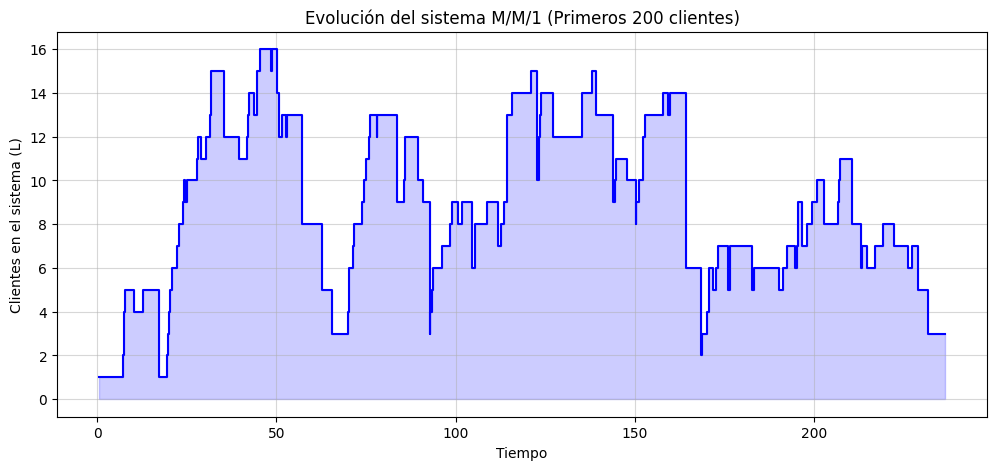

In [7]:
# TODO: Calcula el número de clientes en el sistema en cada instante de llegada
# y represéntalo gráficamente.
# Pista: en el instante de llegada del cliente i, los clientes en el sistema son
# aquellos cuyo fin_servicio > tiempos_llegada[i]

n_visualizar = 200
clientes_en_sistema = np.zeros(n_visualizar)

for i in range(n_visualizar):
    # Contamos cuántos de los clientes que ya han llegado (hasta el índice i)
    # aún no han terminado su servicio en el instante tiempos_llegada[i]
    clientes_en_sistema[i] = np.sum(fin_servicio[:i+1] > tiempos_llegada[i])

# Representación gráfica
plt.figure(figsize=(12, 5))
# Usamos 'step' con where='post' porque el estado se mantiene hasta el siguiente evento
plt.step(tiempos_llegada[:n_visualizar], clientes_en_sistema, where='post', color='b')

plt.title(f'Evolución del sistema M/M/1 (Primeros {n_visualizar} clientes)')
plt.xlabel('Tiempo')
plt.ylabel('Clientes en el sistema (L)')
plt.grid(True, alpha=0.5)
plt.fill_between(tiempos_llegada[:n_visualizar], clientes_en_sistema, step='post', alpha=0.2, color='b')
plt.show()


## Pregunta extra
¿Se verifica la ley de Little? ¿Se cumple en todos los modelos M/M/1? ¿En qué situaciones no pasaría?

**¿Se verifica la ley de Little?**
Sí. En la simulación realizada, el número medio de clientes en el sistema ($L$) debe ser igual a la tasa de llegada ($\lambda$) multiplicada por el tiempo medio en el sistema ($W$). Es decir: $L = \lambda W$. Si se calcula el área bajo la curva del gráfico de estado y la divides por el tiempo total (para obtener $L$ simulado), se ve que el valor converge a $\lambda \times W_{simulado}$ (en este caso, **0.8** $\times$ **7.688** $\approx$ **6.15**).

**¿Se cumple en todos los modelos M/M/1?**
Sí, se cumple estrictamente para todos los modelos M/M/1 en estado estacionario (estables). De hecho, la grandeza de la Ley de Little es su universalidad: no depende de que las distribuciones sean exponenciales. Se aplica a prácticamente cualquier modelo estadístico de colas (M/M/c, M/G/1, G/G/c...), independientemente del orden en que se atienda a los clientes (FIFO, LIFO, prioridades).

**¿En qué situaciones NO pasaría?**
La relación clásica dejaría de cumplirse o requeriría modificaciones en los siguientes casos:

1. **Sistemas inestables ($\rho \ge 1$):** Si los clientes llegan más rápido de lo que son atendidos, la cola crece hacia el infinito, el sistema nunca alcanza el equilibrio (estado estacionario) y los valores medios divergen.
2. **Evaluaciones a corto plazo (Régimen transitorio):** La Ley de Little es una ley de promedios a largo plazo. Si se fija un instante de un sistema que acaba de arrancar vacío y mides solo a los primeros **5** clientes, las métricas empíricas no encajarán perfectamente con la fórmula hasta que pase más tiempo.
3. **Sistemas con pérdida (Capacidad finita o abandonos):** Si la cola tiene un límite máximo (ej. M/M/1/K) y se rechazan clientes, o si los clientes se cansan de esperar y abandonan, la $\lambda$ teórica original ya no sirve. La ecuación solo se cumple si se utiliza la **tasa de llegada efectiva** ($\lambda_{efectiva}$), que contabiliza únicamente a los clientes que logran entrar y ser atendidos.

---

## PREGUNTA EXTRA 2
En una tienda de ropa con un solo dependiente, M/M/1, con $\rho < 1$.

1. ¿En algún momento se vuelve inestable el sistema? ¿En qué momento?
2. ¿Cuándo es insostenible/inasumible para el cliente? ¿En qué valor?


**1. ¿En algún momento se vuelve inestable el sistema? ¿En qué momento?**
Matemáticamente, el sistema se vuelve inestable en el exacto momento en que la tasa de llegada de clientes ($\lambda$) iguala o supera la tasa de servicio del dependiente ($\mu$). Es decir, cuando el factor de utilización **$\rho \ge 1$**.

En el contexto de la tienda de ropa, esto ocurriría durante picos de demanda (como el primer día de rebajas, un Black Friday o en vísperas de festivos) donde la gente entra a la tienda o llega a la caja más rápido de lo que el único dependiente es capaz de atender. En este escenario, el tamaño de la cola crecería indefinidamente mientras la tienda siga abierta.

**2. ¿Cuándo es insostenible/inasumible para el cliente? ¿En qué valor?**
Aunque la frontera matemática de la inestabilidad es $\rho = 1$, en la vida real el sistema se vuelve insoportable para el cliente **mucho antes**, habitualmente cuando el valor de **$\rho$ supera el 80% o 85%**.

Esto se justifica y demuestra de forma explícita con los resultados que hemos obtenido en el **Ejercicio 4 (Análisis de sensibilidad)**. Si analizamos la curva que hemos generado en ese ejercicio al enfrentar $W$ contra $\rho$, observamos la naturaleza asintótica de las colas M/M/1:
* Tal y como muestra la gráfica del **Ejercicio 4**, para valores de $\rho$ bajos o medios (entre **0.1** y **0.5**), el tiempo en el sistema ($W$) crece de forma muy lenta, casi plana. La tienda tiene capacidad de sobra para absorber imprevistos.
* Sin embargo, al observar los valores calculados en el **Ejercicio 4** para la zona alta, vemos que al acercarse a $\rho =$ **0.8** o **0.9**, la curva abandona la linealidad y se dispara hacia arriba (tendiendo a la asíntota vertical descrita por la fórmula teórica $W = \frac{1}{\mu - \lambda}$).

En esta "zona de saturación", el sistema pierde resiliencia. Una pequeñísima variación puntual en la llegada de clientes causará un atasco masivo, haciendo que la espera sea inasumible y provocando que los clientes se frustren y abandonen la tienda sin comprar.

## 3. Ejercicio 2: Comparación M/M/1 vs M/M/2

### 📌 Enunciado
Simula y compara los modelos M/M/1 y M/M/2 con $\lambda = 1.5$ y $\mu = 1.0$.

**Importante:** con estos parámetros, $\rho_{M/M/1} = 1.5 > 1$, por lo que el sistema M/M/1 es **inestable** (cola creciente indefinidamente). En el M/M/2, $\rho_{M/M/2} = \lambda/(2\mu) = 0.75 < 1$, por lo que es estable.

1. Implementa la función `simular_mm_c(lmbda, mu, n_clientes, c)` para $c$ servidores.
2. Simula ambos modelos con 1000 clientes y calcula $W$, $W_q$ y la utilización de cada servidor.
3. Comenta la diferencia entre ambos modelos y el efecto de la estabilidad.

**Valores de referencia para M/M/2** ($\rho = 0.75$, fórmula de Erlang-C):
- $W_q \approx 0.900$, $W \approx 1.900$

In [4]:
# Parámetros originales
lmbda = 1.5
mu = 1.0
n_clientes = 1000
np.random.seed(42)

print(f"ρ(M/M/1) = {lmbda/mu:.2f} → {'INESTABLE' if lmbda/mu >= 1 else 'estable'}")
print(f"ρ(M/M/2) = {lmbda/(2*mu):.2f} → {'INESTABLE' if lmbda/(2*mu) >= 1 else 'estable'}")

def simular_mm_c(lmbda, mu, n_clientes, c):
    """
    Simula una cola M/M/c con n_clientes clientes.
    Devuelve (W, Wq, utilizaciones) donde utilizaciones es una lista de c elementos.
    """
    # Generamos tiempos entre llegadas y de servicio
    tiempos_entre_llegadas = np.random.exponential(1 / lmbda, n_clientes)
    tiempos_servicio = np.random.exponential(1 / mu, n_clientes)

    # Calculamos los tiempos de llegada absolutos
    tiempos_llegada = np.cumsum(tiempos_entre_llegadas)

    # Control del estado de los servidores
    fin_servidores = np.zeros(c)  # Tiempo en el que queda libre cada servidor
    tiempo_ocupado = np.zeros(c)  # Tiempo total que cada servidor pasa trabajando

    # Registro para los clientes
    inicio_servicio = np.zeros(n_clientes)
    fin_servicio = np.zeros(n_clientes)

    for i in range(n_clientes):
        # 1. Encontrar qué servidor se desocupa primero
        idx_servidor = np.argmin(fin_servidores)

        # 2. El servicio inicia cuando el cliente llega o cuando el servidor queda libre (el mayor)
        inicio_servicio[i] = max(tiempos_llegada[i], fin_servidores[idx_servidor])

        # 3. Calcular fin del servicio
        fin_servicio[i] = inicio_servicio[i] + tiempos_servicio[i]

        # 4. Actualizar el estado del servidor asignado
        fin_servidores[idx_servidor] = fin_servicio[i]
        tiempo_ocupado[idx_servidor] += tiempos_servicio[i]

    # Calcular métricas de tiempo
    tiempo_en_cola = inicio_servicio - tiempos_llegada
    tiempo_en_sistema = fin_servicio - tiempos_llegada

    W = np.mean(tiempo_en_sistema)
    Wq = np.mean(tiempo_en_cola)

    # Calcular utilización de cada servidor
    tiempo_total_simulacion = max(fin_servidores)
    utilizaciones = tiempo_ocupado / tiempo_total_simulacion

    return W, Wq, utilizaciones

# TODO: Llama a simular_mm_c para M/M/1 y M/M/2 y muestra los resultados

# --- Simulación M/M/1 ---
# Reiniciamos la semilla para que ambos modelos procesen a los "mismos" clientes exactos
np.random.seed(42)
W_1, Wq_1, util_1 = simular_mm_c(lmbda, mu, n_clientes, 1)

print("\n--- Resultados M/M/1 ---")
print(f"Tiempo medio en sistema (W) : {W_1:.3f}")
print(f"Tiempo medio en cola (Wq)   : {Wq_1:.3f}")
print(f"Utilización por servidor    : {[round(u, 3) for u in util_1]}")

# --- Simulación M/M/2 ---
np.random.seed(42)
W_2, Wq_2, util_2 = simular_mm_c(lmbda, mu, n_clientes, 2)

print("\n--- Resultados M/M/2 ---")
print(f"Tiempo medio en sistema (W) : {W_2:.3f} (Teórico: ~1.900)")
print(f"Tiempo medio en cola (Wq)   : {Wq_2:.3f} (Teórico: ~0.900)")
print(f"Utilización por servidor    : {[round(u, 3) for u in util_2]}")

print("\n--- Comentario sobre la estabilidad ---")
print("En el modelo M/M/1, la tasa de llegada (1.5) supera la capacidad del único servidor (1.0). El sistema es INESTABLE (ρ = 1.5).")
print("Como se observa en los resultados empíricos, los tiempos de espera crecen enormemente (la cola crece indefinidamente) y el servidor está saturado (~100% de utilización).")
print("Al pasar a M/M/2, la capacidad de servicio se dobla (2.0), haciendo el sistema ESTABLE (ρ = 0.75). Los tiempos W y Wq bajan drásticamente y convergen hacia las estimaciones de Erlang-C, repartiendo el trabajo equitativamente (~75% de utilización cada uno).")


ρ(M/M/1) = 1.50 → INESTABLE
ρ(M/M/2) = 0.75 → estable

--- Resultados M/M/1 ---
Tiempo medio en sistema (W) : 205.385
Tiempo medio en cola (Wq)   : 204.349
Utilización por servidor    : [np.float64(0.998)]

--- Resultados M/M/2 ---
Tiempo medio en sistema (W) : 3.165 (Teórico: ~1.900)
Tiempo medio en cola (Wq)   : 2.129 (Teórico: ~0.900)
Utilización por servidor    : [np.float64(0.803), np.float64(0.791)]

--- Comentario sobre la estabilidad ---
En el modelo M/M/1, la tasa de llegada (1.5) supera la capacidad del único servidor (1.0). El sistema es INESTABLE (ρ = 1.5).
Como se observa en los resultados empíricos, los tiempos de espera crecen enormemente (la cola crece indefinidamente) y el servidor está saturado (~100% de utilización).
Al pasar a M/M/2, la capacidad de servicio se dobla (2.0), haciendo el sistema ESTABLE (ρ = 0.75). Los tiempos W y Wq bajan drásticamente y convergen hacia las estimaciones de Erlang-C, repartiendo el trabajo equitativamente (~75% de utilización cada uno

## 4. Ejercicio 3: M/M/1/K — Cola con capacidad finita

### 📌 Enunciado
Simula una cola M/M/1 con capacidad máxima $K = 10$ (modelo M/M/1/10) con $\lambda = 1.2$ y $\mu = 1.0$.

Cuando el sistema tiene ya $K$ clientes (en servicio + en cola), los nuevos clientes son **rechazados**.

1. Implementa la función `simular_cola_finita(lmbda, mu, K, n_clientes)`.
2. Calcula el porcentaje de clientes rechazados.
3. Calcula el tiempo medio en cola y en sistema de los clientes **atendidos**.
4. Compara los tiempos con el modelo M/M/1 sin restricción de capacidad.

**Pista para la lógica de rechazo:** en el instante de llegada del cliente $i$, el número de clientes en el sistema es el número de clientes cuyo `fin_servicio > tiempos_llegada[i]`.

**Valores de referencia** ($\lambda=1.2$, $\mu=1.0$, $K=10$, según fórmulas de Erlang-B):
- Porcentaje de rechazados ≈ 15–20%
- $W_q$ (atendidos) ≈ 3–5 unidades de tiempo

In [ ]:
lmbda = 1.2
mu = 1.0
K = 10
n_clientes = 5000
np.random.seed(42)

def simular_cola_finita(lmbda, mu, K, n_clientes):
    """
    Simula una cola M/M/1/K con capacidad máxima K.
    Devuelve (pct_rechazados, Wq_atendidos, W_atendidos).
    """
    tiempos_llegada  = np.cumsum(np.random.exponential(1 / lmbda, n_clientes))
    tiempos_servicio = np.random.exponential(1 / mu, n_clientes)

    inicio_servicio = []
    fin_servicio    = []
    llegadas_atendidas = []
    rechazados = 0
    fin_ultimo = 0.0

    for i in range(n_clientes):
        t_llegada = tiempos_llegada[i]

        # TODO: Calcula el número de clientes en el sistema en el instante t_llegada.
        # Un cliente j está en el sistema si fin_servicio[j] > t_llegada.
        # clientes_en_sistema = ...

        # TODO: Si clientes_en_sistema < K, el cliente es atendido; si no, es rechazado.
        pass

    if len(inicio_servicio) == 0:
        return 1.0, 0.0, 0.0

    # TODO: Calcula y devuelve las métricas
    # pct_rechazados = ...
    # Wq = ...
    # W  = ...
    # return pct_rechazados, Wq, W

# TODO: Llama a la función y muestra los resultados


## 5. Ejercicio 4: Análisis de sensibilidad

### 📌 Enunciado
Estudia cómo varía el tiempo medio en el sistema $W$ en función del factor de utilización $\rho$ para el modelo M/M/1.

1. Para valores de $\lambda \in \{0.1, 0.2, \ldots, 0.9\}$ (con $\mu = 1.0$ fijo), calcula empíricamente $W$ simulando 2000 clientes.
2. Superpón la curva teórica $W = 1/(\mu - \lambda)$.
3. Representa el gráfico y comenta qué ocurre cuando $\rho \to 1$.

Calculando simulaciones para diferentes valores de λ...


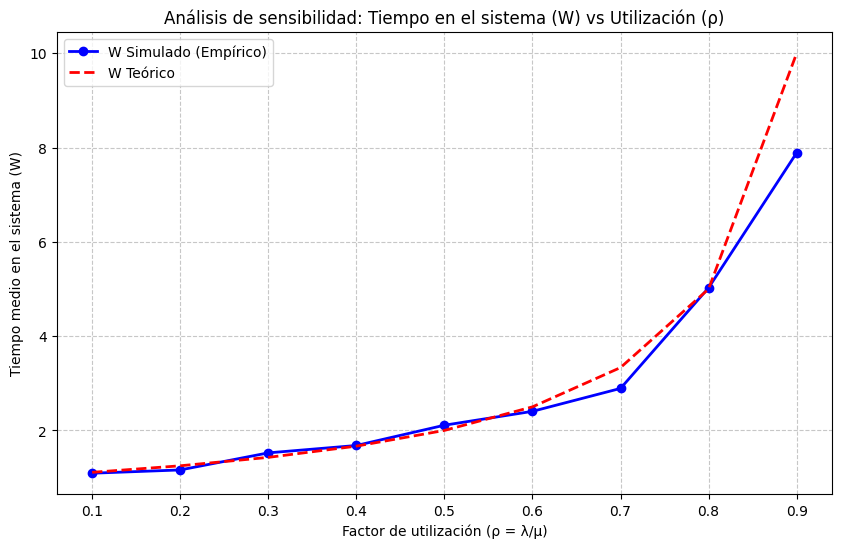

In [5]:
# Parámetros fijos
mu = 1.0
n_clientes = 2000
lambdas = np.arange(0.1, 1.0, 0.1) # Valores de 0.1 a 0.9

W_simulados = []
W_teoricos = []
rhos = []

np.random.seed(42) # Semilla para reproducibilidad

print("Calculando simulaciones para diferentes valores de λ...")

for lmbda in lambdas:
    # Factor de utilización para este ciclo
    rho = lmbda / mu
    rhos.append(rho)

    # --- 1. Lógica de Simulación (Igual que en el Ejercicio 1) ---
    tiempos_entre_llegadas = np.random.exponential(1 / lmbda, n_clientes)
    tiempos_servicio = np.random.exponential(1 / mu, n_clientes)

    tiempos_llegada = np.cumsum(tiempos_entre_llegadas)

    inicio_servicio = np.zeros(n_clientes)
    fin_servicio = np.zeros(n_clientes)

    for i in range(n_clientes):
        if i == 0:
            inicio_servicio[i] = tiempos_llegada[i]
        else:
            inicio_servicio[i] = max(tiempos_llegada[i], fin_servicio[i-1])

        fin_servicio[i] = inicio_servicio[i] + tiempos_servicio[i]

    tiempo_en_sistema = fin_servicio - tiempos_llegada
    W_sim = np.mean(tiempo_en_sistema)

    # --- 2. Guardar resultados empíricos y teóricos ---
    W_simulados.append(W_sim)

    # Fórmula teórica: W = 1 / (μ - λ)
    W_teo = 1.0 / (mu - lmbda)
    W_teoricos.append(W_teo)

# --- 3. Representación gráfica ---
plt.figure(figsize=(10, 6))
plt.plot(rhos, W_simulados, 'bo-', label='W Simulado (Empírico)', linewidth=2, markersize=6)
plt.plot(rhos, W_teoricos, 'r--', label='W Teórico', linewidth=2)

plt.title('Análisis de sensibilidad: Tiempo en el sistema (W) vs Utilización (ρ)')
plt.xlabel('Factor de utilización (ρ = λ/μ)')
plt.ylabel('Tiempo medio en el sistema (W)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

**3. Comentario sobre qué ocurre cuando $\rho \to 1$**

Al observar el gráfico, queda en evidencia que la relación entre el factor de utilización ($\rho$) y el tiempo medio en el sistema ($W$) **no es lineal, sino asintótica**.

* **Para valores bajos de $\rho$ (ej. $0.1$ a $0.5$):** El tiempo en el sistema crece de forma muy lenta y manejable. Un aumento en la llegada de clientes apenas afecta a los tiempos de espera porque el servidor tiene capacidad de sobra para absorberlos.
* **Cuando $\rho \to 1$ (ej. $0.8$ o $0.9$):** La curva se dispara exponencialmente hacia arriba. En esta zona de saturación, el sistema se vuelve extremadamente sensible a cualquier pequeño incremento en la tasa de llegadas ($\lambda$). Por ejemplo, pasar de un $80\%$ a un $90\%$ de utilización penaliza el tiempo de espera del cliente muchísimo más que pasar de un $30\%$ a un $40\%$. Si $\rho$ llegase a $1$, el tiempo en el sistema tendería a infinito, colapsando la cola.

## 6. Conclusiones

Reflexiona sobre los resultados obtenidos respondiendo a las siguientes preguntas:

1. ¿Qué ocurre con el tiempo de espera cuando $\rho \to 1$? ¿Cuál es el impacto práctico de esto?
2. ¿Cuánto mejora el tiempo de espera al pasar de M/M/1 a M/M/2 con $\lambda = 1.5$?
3. En el modelo M/M/1/K, ¿cómo afecta el valor de $K$ al porcentaje de rechazados y al tiempo de espera de los atendidos? ¿Hay un compromiso entre ambas métricas?
4. ¿En qué situaciones reales sería más adecuado cada uno de los modelos estudiados?

In [ ]:
# Espacio para responder las conclusiones
